## **1. Importation et installation des librairies**

In [1]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
from IPython.display import Image, display
import cv2
import random
from PIL import Image as PILImage
import numpy as np

## **2. Téléchargement de la base de données d'entrainement : BIG**

## **2.1 Téléchargement de la base de données d'entrainement : Small**

## **2.2 Téléchargement de la base de données annotée de test**

## **3. Paramètres d'entrainement**

In [ ]:
# Define interactive parameters
dataset_path = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/"  #@param ["dataset/dataset_segmentation/","dataset/MOCS_Small_Seg/","dataset/MOCS_Big_Seg/"] {type:"string"}
model_to_be_trained = "yolo11s-seg"  #@param ["yolo11n-seg"]
nbr_epochs = 50  #@param {type:"integer"}
img_size = 640  #@param {type:"integer"}
batch_size = 32  #@param {type:"integer"}
load_weights = True  #@param {type:"boolean"}
test_conf_level = 0.4  #@param {type:"slider", min:0, max:1, step:0.05}

In [3]:
# Set hyperparameters manually for compatibility with argparse usage
class Args:
    epochs = nbr_epochs
    imgsz = img_size
    batch = batch_size
    test_images = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/test/images/"
args = Args()

## **4. Visualisation d'exemples d'images annotées**


## **5. Télachargement du modèle Yolo V11**

In [4]:
##CORRECTED THE TAB
model = YOLO(model_to_be_trained)# Load YOLOv11 object detection model

## **6. Définition du fichier de configuration data.yaml**

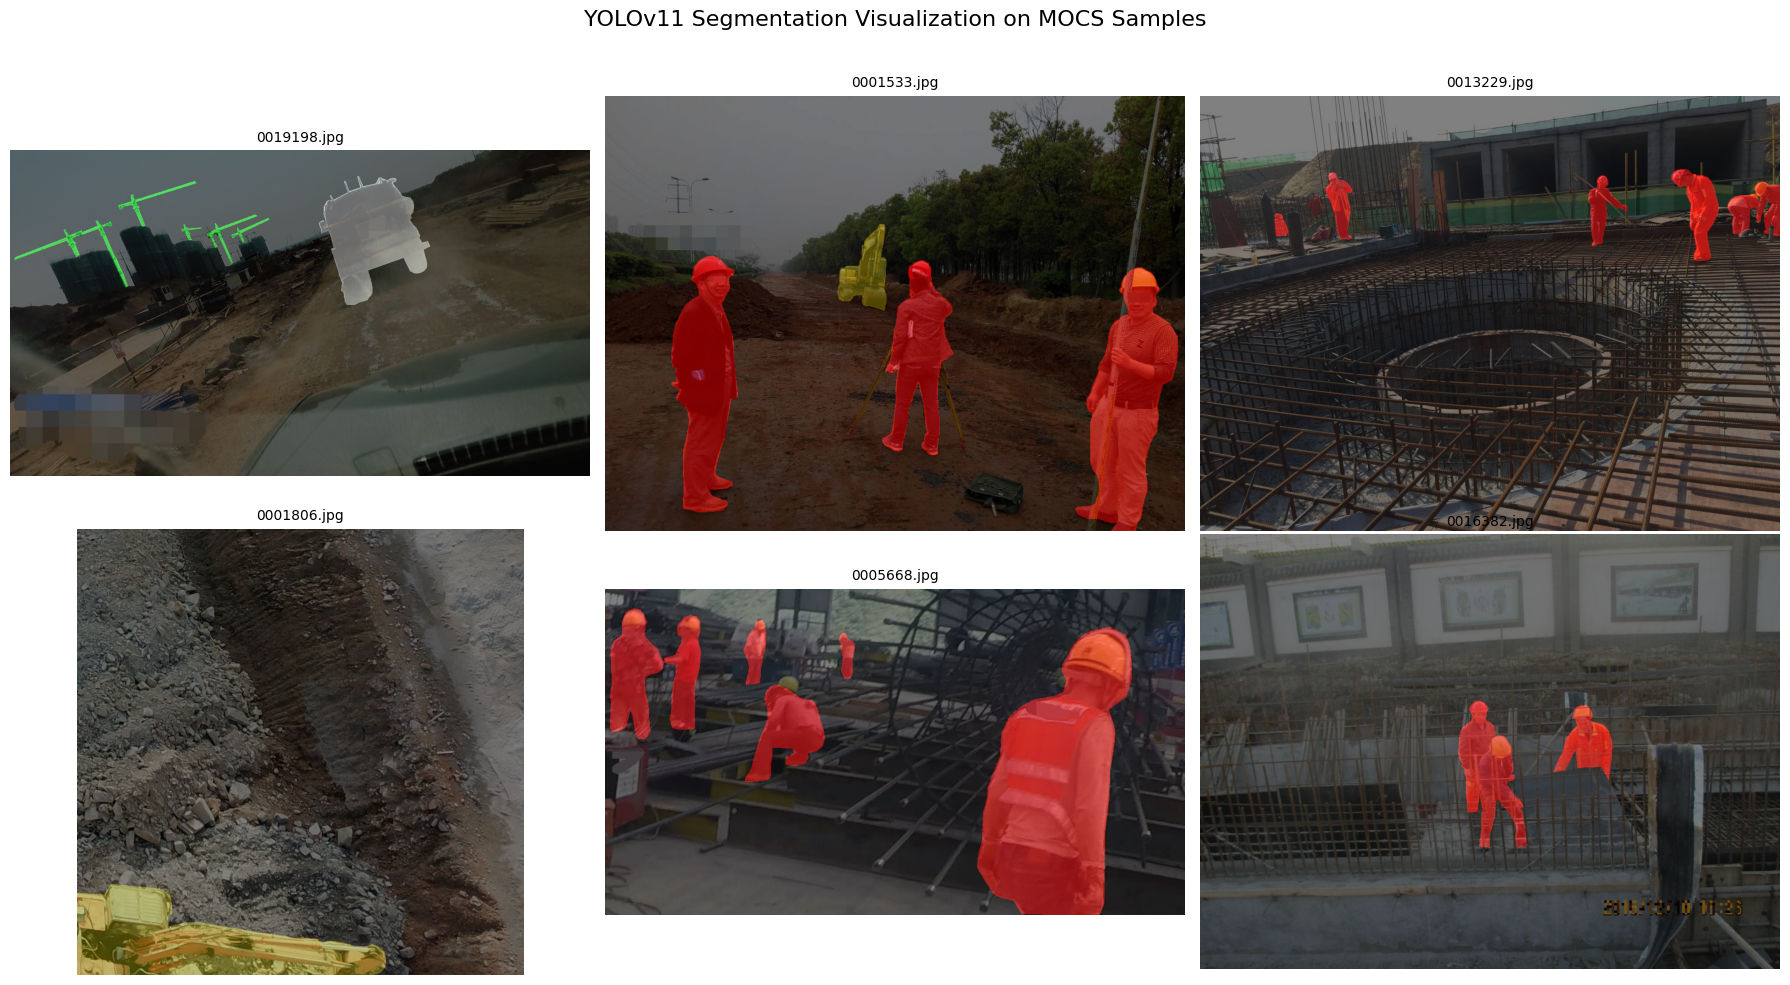

In [5]:


# Directories
image_dir = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/test/images/"
label_dir = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/test/labels/"

# Class color map (class_id: BGR)
CLASS_COLORS = {
    0: (0, 0, 0),
    1: (255, 0, 0),     # Red - Worker
    2: (0, 255, 0),     # Green - Static crane
    3: (0, 0, 255),     # Blue - Hanging head
    4: (255, 255, 0),   # Cyan - Crane
    5: (255, 0, 255),   # Magenta - Roller
    6: (0, 255, 255),   # Yellow - Bulldozer
    7: (128, 128, 0),   # Olive - Excavator
    8: (128, 0, 128),   # Purple - Truck
    9: (0, 128, 128),   # Teal - Loader
    10: (100, 100, 255),# Light Blue - Pump truck
    11: (255, 100, 100),# Salmon - Concrete mixer
    12: (100, 255, 100),# Light Green - Pile driving
    13: (200, 200, 200) # Gray - Other vehicle
}

# Get image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]
sample_images = random.sample(image_files, 6)

# Function to overlay mask
def visualize_segmentation(img_path, label_path):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    mask = np.zeros_like(image, dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                elements = line.strip().split()
                class_id = int(elements[0])
                coords = list(map(float, elements[1:]))
                poly = np.array([[int(x * w), int(y * h)] for x, y in zip(coords[::2], coords[1::2])], dtype=np.int32)
                color = CLASS_COLORS.get(class_id, (255, 255, 255))
                cv2.fillPoly(mask, [poly], color=color)

    alpha = 0.5
    overlayed = cv2.addWeighted(image, 1 - alpha, mask, alpha, 0)
    return overlayed

# Plotting
plt.figure(figsize=(18, 10))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt").replace(".png", ".txt"))
    vis_img = visualize_segmentation(img_path, label_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(vis_img)
    plt.title(f"{img_name}", fontsize=10)
    plt.axis("off")

plt.suptitle("YOLOv11 Segmentation Visualization on MOCS Samples", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


In [6]:
%%writefile data.yaml

path: C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/
val: val
test: test
train: train
names:
  0: background
  1: Worker
  2: Static crane
  3: Hanging head
  4: Crane
  5: Roller
  6: Bulldozer
  7: Excavator
  8: Truck
  9: Loader
  10: Pump truck
  11: Concrete mixer
  12: Pile driving
  13: Other vehicle

Overwriting data.yaml


## **7. Lancement de l'entrainement**

In [7]:
results = model.train(
    data="C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/data.yaml",
    epochs=args.epochs,
    imgsz=args.imgsz,
    batch=args.batch,
    pretrained=load_weights,
    project="runs/train_segmentation_yolo",
    name="YOLOv11_MOCS_10epochs"
)

New https://pypi.org/project/ultralytics/8.3.128 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.127  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=

100%|██████████| 5.35M/5.35M [00:03<00:00, 1.68MB/s]


AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 225.061.1 MB/s, size: 256.0 KB)


train: Scanning C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\train\labels.cache... 19404 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19404/19404 [00:00<?, ?it/s]

train: C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\train\images\0008711.jpg: 1 duplicate labels removed
train: C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\train\images\0015612.jpg: 1 duplicate labels removed


val: Fast image access  (ping: 0.10.0 ms, read: 210.1153.3 MB/s, size: 361.9 KB)


val: Scanning C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\val\labels.cache... 4000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4000/4000 [00:00<?, ?it/s]


Plotting labels to runs\train_segmentation_yolo\YOLOv11_MOCS_10epochs\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000556, momentum=0.9) with parameter groups 90 weight(decay=0.0), 101 weight(decay=0.0005), 100 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\train_segmentation_yolo\YOLOv11_MOCS_10epochs
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


       1/10      9.22G      1.254      2.317      3.745      1.135        253        640:  12%|█▏        | 72/607 [00:47<05:50,  1.53it/s]


KeyboardInterrupt: 

## **8. Evaluation du modèle**

In [8]:
metrics = model.val(data="C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/data.yaml", split="test")

Ultralytics 8.3.127  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16380MiB)
YOLO11n-seg summary (fused): 113 layers, 2,837,298 parameters, 0 gradients, 10.2 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 40.318.5 MB/s, size: 392.3 KB)


val: Scanning C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\test\labels... 388 images, 0 backgrounds, 0 corrupt: 100%|██████████| 388/388 [00:00<00:00, 430.56it/s]


val: New cache created: C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\test\labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/13 [00:00<?, ?it/s]

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validati

...

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validati

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  15%|█▌        | 2/13 [00:02<00:11,  1.05s/it]

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validati

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:06<00:00,  1.91it/s]


                   all        388       2254      0.853      0.681       0.76      0.593      0.836      0.669      0.731      0.464
                Worker        299       1438      0.939      0.618      0.805      0.521      0.905      0.598      0.758      0.419
          Static crane         76        143      0.864      0.685      0.796      0.627      0.846      0.671      0.756      0.479
          Hanging head         42         55      0.841      0.473       0.55      0.391      0.808      0.455       0.52      0.278
                 Crane         45         54       0.84       0.68      0.721      0.571       0.84      0.681       0.72      0.381
                Roller         18         19      0.859      0.895      0.897      0.771      0.858      0.895      0.897      0.704
             Bulldozer         18         21      0.913       0.81      0.897      0.675      0.904       0.81      0.878      0.584
             Excavator        137        198      0.915      0.808   

## **9- Téléchargement de la base de données de test**

## **10. Tester le modèle sur des images de test**

## **11. Visuliser les résultats (Confusion Matrix, PR Curve, etc.)**

## **12. Tester le modèle avec une image de test**

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Color map (class_id: BGR)
CLASS_COLORS = {
    0: (0, 0, 0),
    1: (255, 0, 0),     # Red - Worker
    2: (0, 255, 0),     # Green - Static crane
    3: (0, 0, 255),     # Blue - Hanging head
    4: (255, 255, 0),   # Cyan - Crane
    5: (255, 0, 255),   # Magenta - Roller
    6: (0, 255, 255),   # Yellow - Bulldozer
    7: (128, 128, 0),   # Olive - Excavator
    8: (128, 0, 128),   # Purple - Truck
    9: (0, 128, 128),   # Teal - Loader
    10: (100, 100, 255),# Light Blue - Pump truck
    11: (255, 100, 100),# Salmon - Concrete mixer
    12: (100, 255, 100),# Light Green - Pile driving
    13: (200, 200, 200) # Gray - Other vehicle
}

def draw_segmented_labels(image_path, label_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    mask = np.zeros_like(image, dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                elements = line.strip().split()
                class_id = int(elements[0])
                coords = list(map(float, elements[1:]))

                poly = np.array([[int(x * w), int(y * h)] for x, y in zip(coords[::2], coords[1::2])], dtype=np.int32)
                color = CLASS_COLORS.get(class_id, (255, 255, 255))
                cv2.fillPoly(mask, [poly], color=color)

    blended = cv2.addWeighted(image, 0.7, mask, 0.3, 0)
    return blended



image 1/1 C:\Users\Sacha\Desktop\Mini-Projet\Segmentation\dataset_segmentation\test\images\0000014.jpg: 480x640 3 Excavators, 2 Trucks, 76.1ms
Speed: 6.0ms preprocess, 76.1ms inference, 21.3ms postprocess per image at shape (1, 3, 480, 640)


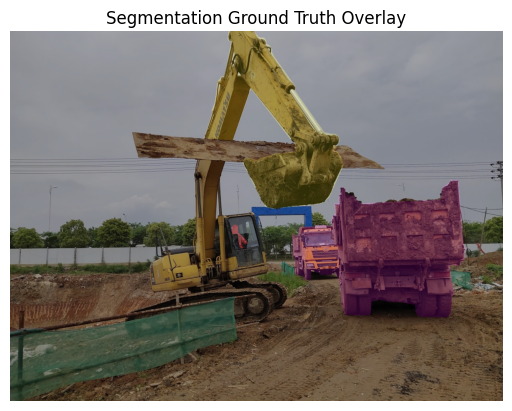

In [10]:
# Example usage
image_path = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/test/images/0000014.jpg"
label_path = "C:/Users/Sacha/Desktop/Mini-Projet/Segmentation/dataset_segmentation/test/labels/0000014.txt"

results = model.predict(source=image_path, conf=0.25)
results[0].show()

##CORRECTED THE draw_bboxes script
#comparaison avec la première image du dataset
vis_img = draw_segmented_labels(image_path, label_path)
plt.imshow(vis_img)
plt.axis("off")
plt.title("Segmentation Ground Truth Overlay")
plt.show()


#vis_img = draw_bboxes(image_path, "/home/zainab/Desktop/Project_thesis/benshmark/student_notebooks/Test_Seg/labels/0000014.txt")
#plt.imshow(vis_img)

## **13. Tester le modèle avec une vidéo de test**

In [13]:
from ultralytics import YOLO

# Path to your trained weights
model = YOLO("runs/train_segmentation_yolo/YOLOv11_MOCS_10epochs/weights/best.pt")

# Path to the test video
video_path = "example_video.mp4"

# Prediction and Save
model.predict(
    source=video_path,
    save=True,
    conf=0.25,
    iou=0.45,
    stream=False,
    show=False,
    project="runs/segment",  # Where to save
    name="example_video_output",     # Subdirectory
    exist_ok=True
)



WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/931) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\example_video.mp4: 384x640 4 Workers, 4 Excavators, 3 Other vehicles, 73.4ms
video 1/1 (frame 2/931) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\example_video.mp4: 384x640 4 Workers, 4 Excavators, 3 Other vehicles, 13.3ms
video 1/1 (frame 3/931) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\example_video.mp4: 384x640 4 Workers, 4 Excavators, 3 Other vehicles, 13.5ms
video 1/1 (f

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'background', 1: 'Worker', 2: 'Static crane', 3: 'Hanging head', 4: 'Crane', 5: 'Roller', 6: 'Bulldozer', 7: 'Excavator', 8: 'Truck', 9: 'Loader', 10: 'Pump truck', 11: 'Concrete mixer', 12: 'Pile driving', 13: 'Other vehicle'}
 obb: None
 orig_img: array([[[220, 196, 166],
         [220, 196, 166],
         [220, 196, 166],
         ...,
         [208, 179, 136],
         [208, 179, 136],
         [208, 179, 136]],
 
        [[220, 196, 166],
         [220, 196, 166],
         [220, 196, 166],
         ...,
         [208, 179, 136],
         [208, 179, 136],
         [208, 179, 136]],
 
        [[220, 196, 166],
         [220, 196, 166],
         [220, 196, 166],
         ...,
         [208, 179, 136],
         [208, 179, 136],
         [208, 179, 136]],
 
        ...,
 
        [[120, 136, 136],
    

In [14]:
from ultralytics import YOLO

# Path to your trained weights
model = YOLO("runs/train_segmentation_yolo/YOLOv11_MOCS_10epochs/weights/best.pt")

# Path to the test video
video_path = "unity_video.mp4"

# Prediction and Save
model.predict(
    source=video_path,
    save=True,
    conf=0.25,
    iou=0.45,
    stream=False,
    show=False,
    project="runs/segment",  # Where to save
    name="unity_video_output",     # Subdirectory
    exist_ok=True
)



WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/394) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\unity_video.mp4: 384x640 8 Workers, 1 Static crane, 1 Excavator, 2 Trucks, 13.5ms
video 1/1 (frame 2/394) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\unity_video.mp4: 384x640 11 Workers, 1 Static crane, 1 Crane, 1 Excavator, 2 Trucks, 13.2ms
video 1/1 (frame 3/394) c:\Users\Sacha\Desktop\Mini-Projet\Segmentation\unity_video.mp4: 384x640 9 Workers, 1 Static crane, 1 Crane, 1 Truck,

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'background', 1: 'Worker', 2: 'Static crane', 3: 'Hanging head', 4: 'Crane', 5: 'Roller', 6: 'Bulldozer', 7: 'Excavator', 8: 'Truck', 9: 'Loader', 10: 'Pump truck', 11: 'Concrete mixer', 12: 'Pile driving', 13: 'Other vehicle'}
 obb: None
 orig_img: array([[[ 32,  34,  50],
         [ 32,  34,  50],
         [ 32,  34,  50],
         ...,
         [102,  97,  98],
         [102,  97,  98],
         [102,  97,  98]],
 
        [[ 32,  34,  50],
         [ 32,  34,  50],
         [ 32,  34,  50],
         ...,
         [ 94,  89,  90],
         [ 94,  89,  90],
         [ 94,  89,  90]],
 
        [[ 31,  33,  49],
         [ 31,  33,  49],
         [ 31,  33,  49],
         ...,
         [ 94,  89,  90],
         [ 94,  89,  90],
         [ 94,  89,  90]],
 
        ...,
 
        [[ 89,  84,  83],
    